In [ ]:
import pandas as pd

df = pd.read_csv("/content/continuous dataset.csv")
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
import pandas as pd

file_path = "/content/continuous dataset.csv"   # same file path you used earlier

# Load
df = pd.read_csv(file_path)

# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'])

# Sort & set index
df = df.sort_values('datetime').set_index('datetime')

print("Data loaded and cleaned!")
df.head()


Data loaded and cleaned!


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
# Make data hourly (some datasets skip hours)
df = df.asfreq('H')

# Check missing values
print("Missing values before filling:")
print(df.isna().sum())

# Fill missing demand values by interpolation
df['nat_demand'] = df['nat_demand'].interpolate(method='time').ffill().bfill()

# For other numeric columns (weather, etc.)
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    if col != 'nat_demand':
        df[col] = df[col].interpolate(method='time').ffill().bfill()

# Categorical holiday/school → fill with 0
for col in ['Holiday_ID', 'holiday', 'school']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

print("\nMissing values after filling:")
print(df.isna().sum())

df.head()

/tmp/ipython-input-3545078619.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


Missing values before filling:
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64

Missing values after filling:
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
# Copy dataframe
data = df.copy()

# Time features
data["hour"] = data.index.hour
data["dayofweek"] = data.index.dayofweek
data["month"] = data.index.month
data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)

# Lag features (past demand)
lags = [1, 24, 48, 168]  # 1hr, 1day, 2days, 1week
for lag in lags:
    data[f"lag_{lag}"] = data["nat_demand"].shift(lag)

# Rolling averages
data["rolling_3h_mean"] = data["nat_demand"].rolling(3).mean().shift(1)
data["rolling_24h_mean"] = data["nat_demand"].rolling(24).mean().shift(1)

# Remove rows that cannot form lags
data = data.dropna()

print("Feature engineering complete!")
data.head()


Feature engineering complete!


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_48,lag_168,rolling_3h_mean,rolling_24h_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-10 01:00:00,906.9580,24.976495,0.017215,0.025253,21.335333,23.554620,0.016421,0.051376,12.485627,22.288995,...,1,5,1,1,949.5031,943.6081,962.4068,970.3450,991.072567,999.013846
2015-01-10 02:00:00,863.5135,24.906274,0.017337,0.034378,22.177057,23.429712,0.016337,0.038712,12.949576,22.296899,...,2,5,1,1,906.9580,917.0640,928.1036,912.1755,948.770600,997.486758
2015-01-10 03:00:00,848.4447,24.879724,0.017512,0.045349,22.742188,23.309412,0.016292,0.028526,13.091533,22.325037,...,3,5,1,1,863.5135,895.9092,917.9997,900.2688,906.658200,995.255488
2015-01-10 04:00:00,839.8821,24.907922,0.017673,0.047501,22.630025,23.306360,0.016337,0.016182,13.050650,22.368860,...,4,5,1,1,848.4447,885.2720,910.9537,889.9538,872.972067,993.277800
2015-01-10 05:00:00,847.1073,24.932520,0.017795,0.036087,21.731658,23.354395,0.016422,0.009590,12.846088,22.424707,...,5,5,1,1,839.8821,884.8111,928.7240,893.6865,850.613433,991.386554


In [ ]:
from datetime import timedelta

# Define the test period (last 1 year)
last_date = data.index.max()
test_start = last_date - timedelta(days=365)

# Split
train = data[data.index < test_start]
test = data[data.index >= test_start]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Features (all except target)
target = "nat_demand"
features = [col for col in data.columns if col != target]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Feature count:", len(features))


Train shape: (39119, 26)
Test shape: (8761, 26)
Feature count: 25


In [ ]:
# Install xgboost if not already installed
!pip install xgboost -q

import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Model training complete!")


Model training complete!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MODEL PERFORMANCE:")
print(f"MAE  = {mae:.3f} MW")
print(f"RMSE = {rmse:.3f} MW")
print(f"MAPE = {mape:.2f}%")


MODEL PERFORMANCE:
MAE  = 17.984 MW
RMSE = 25.045 MW
MAPE = 1.51%


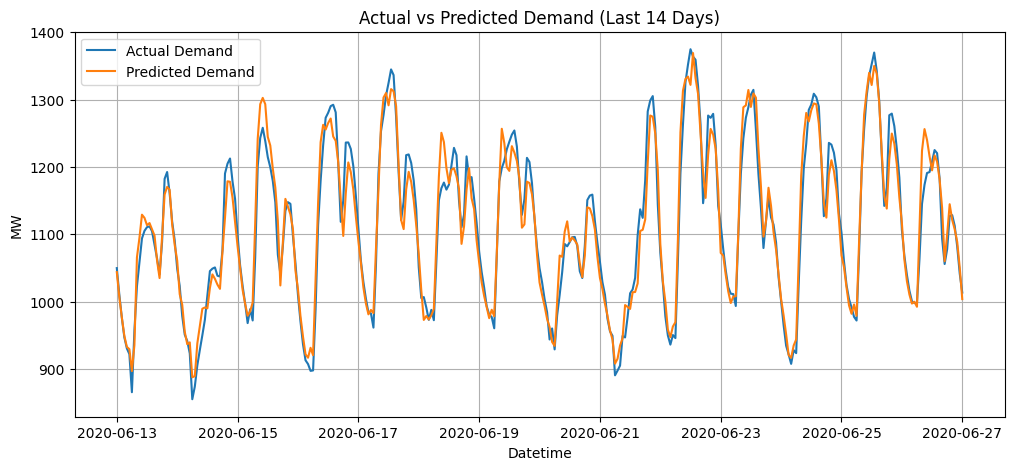

In [ ]:
import matplotlib.pyplot as plt

# Select the last 14 days from the test set
plot_start = y_test.index.max() - pd.Timedelta(days=14)
test_period = y_test.loc[plot_start:]
pred_period = y_pred[-len(test_period):]

plt.figure(figsize=(12,5))
plt.plot(test_period.index, test_period, label="Actual Demand")
plt.plot(test_period.index, pred_period, label="Predicted Demand")
plt.title("Actual vs Predicted Demand (Last 14 Days)")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ---- STEP 11: 1-Week Ahead Forecast ----

future_steps = 168   # next 168 hours = 7 days
future_index = pd.date_range(start=data.index.max() + pd.Timedelta(hours=1),
                             periods=future_steps, freq='H')

# Create empty forecast dataframe
future_df = pd.DataFrame(index=future_index)

# We will use the last known data as "history" for lags
history = data.copy()

for ts in future_index:
    row = {}

    # Time-based features
    row["hour"] = ts.hour
    row["dayofweek"] = ts.dayofweek
    row["month"] = ts.month
    row["is_weekend"] = int(ts.dayofweek in [5, 6])

    # Holidays not available → assume no holiday
    for c in ["Holiday_ID", "holiday", "school"]:
        if c in data.columns:
            row[c] = 0

    # Weather values – since we don't have future weather, use last observed values
    weather_cols = [c for c in df.columns if c not in ["nat_demand", "Holiday_ID", "holiday", "school"]]
    for c in weather_cols:
        row[c] = history[c].iloc[-1]

    # Lag features
    for lag in [1, 24, 48, 168]:
        lag_time = ts - pd.Timedelta(hours=lag)
        if lag_time in history.index:
            row[f"lag_{lag}"] = history.loc[lag_time, "nat_demand"]
        else:
            row[f"lag_{lag}"] = history["nat_demand"].iloc[-1]

    # Rolling features
    row["rolling_3h_mean"]  = history["nat_demand"].iloc[-3:].mean()
    row["rolling_24h_mean"] = history["nat_demand"].iloc[-24:].mean()

    # Convert row to DataFrame
    row_df = pd.DataFrame([row], index=[ts])
    row_df = row_df[data.columns.drop("nat_demand")]  # ensure correct order

    # Predict
    pred = model.predict(row_df)[0]
    future_df.loc[ts, "nat_demand"] = pred

    # Add this prediction to history for next lags
    combined_row = row.copy()
    combined_row["nat_demand"] = pred
    history.loc[ts] = combined_row

print("Forecasting complete!")
future_df.head()


/tmp/ipython-input-2849688502.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(start=data.index.max() + pd.Timedelta(hours=1),


Forecasting complete!


,nat_demand
2020-06-27 01:00:00,983.697144
2020-06-27 02:00:00,962.527893
2020-06-27 03:00:00,942.117554
2020-06-27 04:00:00,928.438538
2020-06-27 05:00:00,932.586670


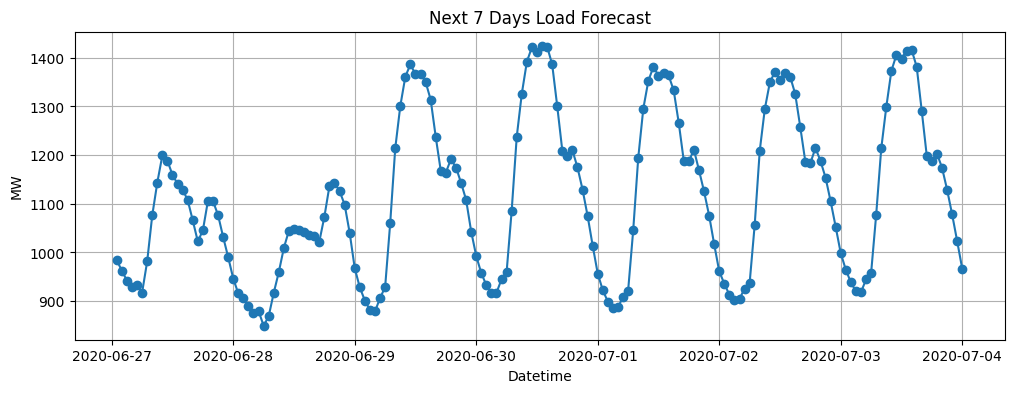

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(future_df["nat_demand"], marker="o")
plt.title("Next 7 Days Load Forecast")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.grid(True)
plt.show()


In [ ]:
future_df.to_csv("7_day_forecast_predictions.csv")
print("✅ Forecast CSV saved!")


✅ Forecast CSV saved!


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from xgboost import plot_importance


In [ ]:
# Make sure y_test and y_pred are numpy arrays
y_test_arr = np.array(y_test)
y_pred = model.predict(X_test)

# Check lengths
print(f"Length of y_test: {len(y_test_arr)}, Length of y_pred: {len(y_pred)}")

# If lengths mismatch, slice y_pred to match y_test
if len(y_test_arr) != len(y_pred):
    y_pred = y_pred[:len(y_test_arr)]
    print(f"Sliced y_pred to match y_test length: {len(y_pred)}")


Length of y_test: 336, Length of y_pred: 8761
Sliced y_pred to match y_test length: 336


**LOSS** **GRAPH**

No evals_result available. Skipping loss graph.


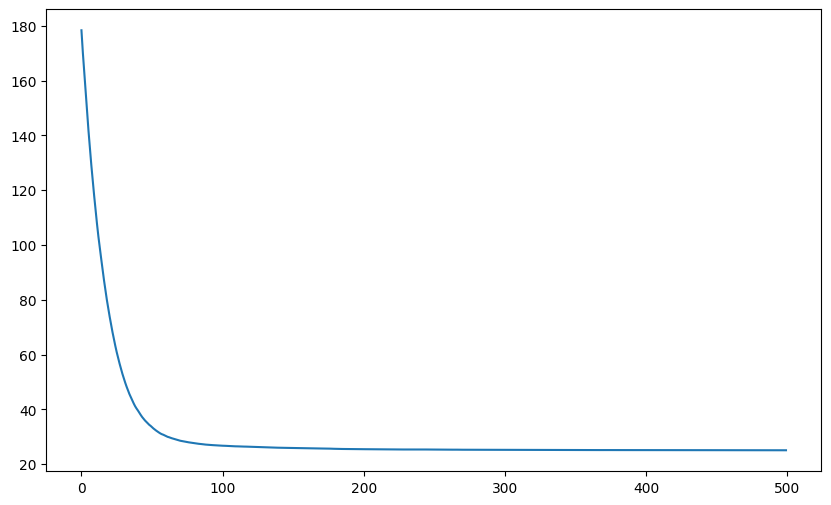

In [ ]:
plt.figure(figsize=(10,6))

try:
    evals_result = model.evals_result()
    epochs = len(evals_result['validation_0']['rmse'])
    x_axis = range(0, epochs)

    plt.plot(x_axis, evals_result['validation_0']['rmse'], label='Train')
    plt.plot(x_axis, evals_result['validation_1']['rmse'], label='Test')
    plt.xlabel('Epochs')
    plt.ylabel('RMSE')
    plt.title('XGBoost RMSE Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()
except:
    print("No evals_result available. Skipping loss graph.")


**Feature Importance**

<Figure size 1000x600 with 0 Axes>

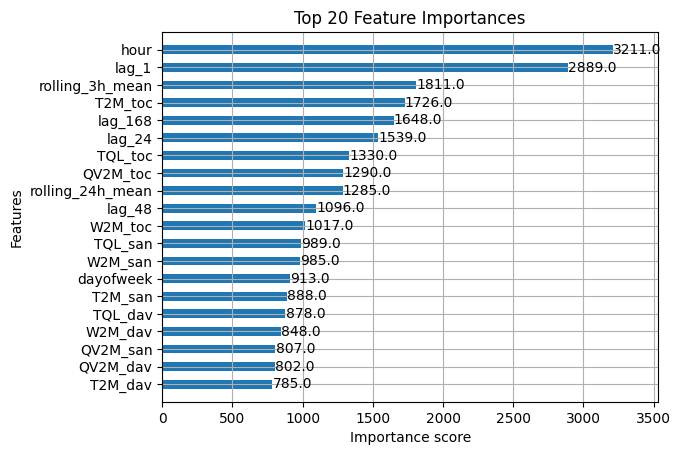

In [ ]:
plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=20, height=0.5)
plt.title('Top 20 Feature Importances')
plt.show()


**ERROR** **DISTRIBUTION**

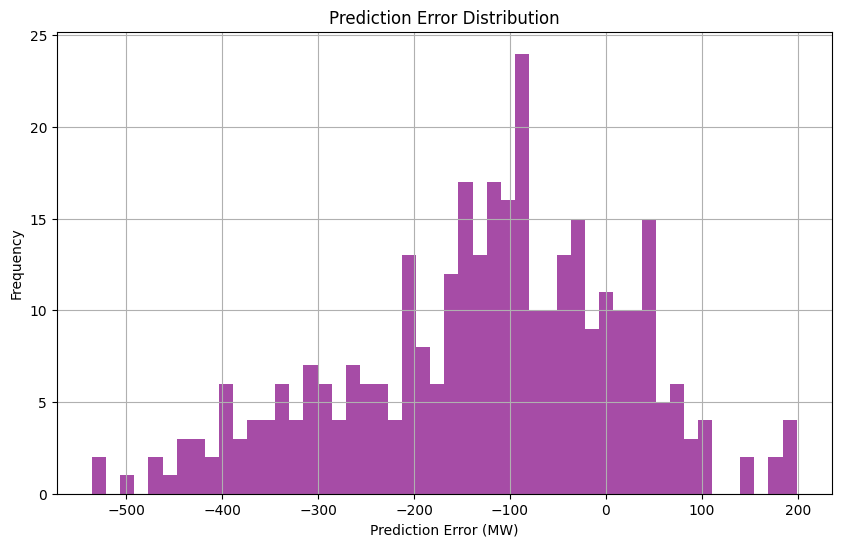

In [ ]:
errors = y_test_arr - y_pred
plt.figure(figsize=(10,6))
plt.hist(errors, bins=50, color='purple', alpha=0.7)
plt.xlabel('Prediction Error (MW)')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.grid(True)
plt.show()
